In [3]:
"""
S&P 500 SMA Crossover Strategy

Author: Will Bunch

Description:
This project evaluates SMA crossover trading strategies on S&P 500 equities
using rolling train/test windows and compares performance against an
equal-weight buy-and-hold benchmark.

Tools:
- Python
- Pandas
- NumPy
- Matplotlib
- yFinance
"""

'\nS&P 500 SMA Crossover Strategy\n\nAuthor: Will Bunch\n\nDescription:\nThis project evaluates SMA crossover trading strategies on S&P 500 equities\nusing rolling train/test windows and compares performance against an\nequal-weight buy-and-hold benchmark.\n\nTools:\n- Python\n- Pandas\n- NumPy\n- Matplotlib\n- yFinance\n'

In [2]:
#download and clean historical price data
#Saves to a diffrent CSV file because our analysis is written on the original data donwloaded
#import libraries
import pandas as pd
import yfinance as yf
import requests

In [3]:
#get S&P tickers list from wiki
#pd.read_html(url) failed
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Header makes the request look like it is coming from a normal browser
headers = {"User-Agent": "Mozilla/5.0"}

#Downloads the web page and store in variable response
response = requests.get(url, headers=headers)

#Convert HTML table to pandas df
sp500 = pd.read_html(response.text)[0]

tickers = sp500["Symbol"].tolist()

# Yahoo Finance uses '-' instead of '.' for some tickers
#Need to format like this to make compatible with yfinance
tickers = [ticker.replace(".", "-") for ticker in tickers]

print(tickers[:10])
print(len(tickers))

C:\Users\willi\AppData\Local\Temp\ipykernel_7764\3695229691.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500 = pd.read_html(response.text)[0]


['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']
503


In [4]:
#Set up csv and set download parameters
csv_filename = "projectstocksexample.csv"
start_date = "2018-01-01"
end_date = None

In [5]:
#Download adjusted closing price data from YFinance
#Bulk download used instead of looping through individual tickers for faster and more efficient data collection
data = yf.download(tickers,start=start_date,end=end_date,auto_adjust=False,progress=False)
#Only closing prices
prices = data["Close"]

In [6]:
#Check dataset dimensions
print(prices.shape)
prices.head()
prices.info()

(2110, 503)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2110 entries, 2018-01-02 to 2026-05-26
Columns: 503 entries, A to ZTS
dtypes: float64(503)
memory usage: 8.1 MB


In [7]:
#Count missing prices for each ticker
prices.isna().sum().sort_values(ascending=False).head(20)

Ticker
Q       1965
SNDK    1789
GEV     1568
SOLV    1567
VLTO    1448
KVUE    1343
GEHC    1248
CEG     1019
HOOD     899
APP      826
COIN     825
EXE      782
ABNB     741
DASH     740
PLTR     691
OTIS     556
CARR     556
DDOG     431
CRWD     362
CTVA     350
dtype: int64

In [8]:
#Remove stocks with incomplete price history
#Same sample length per each stock
prices = prices.dropna(axis=1)

In [9]:
#Save cleaned price data to csv
#avoid results changing after every yfinance update
prices.to_csv(csv_filename)

In [10]:
####STRATEGY START####

In [11]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [12]:
#Set up prices and tickers variable in relation to dataset data for later use
#load data from CSV into a dataframe
prices = pd.read_csv("projectstocks.csv")

#Convert date column to datetime format
prices["datetime"] = pd.to_datetime(prices["Date"])

#set datetime as index so we can use functions properly
prices = prices.set_index("datetime")
prices = prices.drop(columns=["Date"])

tickers = list(prices.columns.values)

In [13]:
print(len(tickers))

476


In [14]:
#logarithmic returns daily
#shift makes it todays price over yesterdays price
#log makes them additive over time
def log_return(dailyprice):
    return np.log(dailyprice / dailyprice.shift(1))

In [15]:
#Modularized evaluation process in a  function
#Backtesting function: evaluates SMA crossover strategy performance
def trading_results(price_data, ticker, short_w, long_w, use_vol_filter=False, vol_window=20, vol_threshold=0.025):
    df = pd.DataFrame()
    
    #Daily log returns of the asset 
    df["underlying_asset"] = log_return(price_data[ticker])
    
    #moving averages
    df["SMA1"] = price_data[ticker].rolling(short_w).mean()
    df["SMA2"] = price_data[ticker].rolling(long_w).mean()
    
    #Original SMA signal
    df["sma_signal"] = np.where(df["SMA1"]>df["SMA2"],1,-1)

    #Optional volatility filter
    if use_vol_filter == True:
        df["volatility"] = df["underlying_asset"].rolling(vol_window).std()
        df["positions"] = np.where(df["volatility"] > vol_threshold, 0, df["sma_signal"])
    else:
        df["positions"] = df["sma_signal"]
    
    #strategy returns using previous days position (via .shift)
    df["strategy"] = df["positions"].shift(1) * df["underlying_asset"]
    df = df.dropna()
    T = len(df)
    
    #Annualised strategy and buy and hold returns to be printed 
    strategy_return = df["strategy"].sum() * (250 / T)
    buy_hold_return = df["underlying_asset"].sum() * (250 / T)
    
    #Annualised outperformance vs buy and hold- Strategy return - buy and hold return
    performance = (df["strategy"]-df["underlying_asset"]).sum() * (250/T)
    return performance, strategy_return, buy_hold_return

In [16]:
#ranges to test for short-20-61 stepping in 5s so its roughly weekly increments between 1-3 months
short_windows = range(20,61,5)

#ranges to test for long- 180-281 in steps of 10- roughly bi-monthly increments
long_windows = range(180, 281, 10)

#Volatility filter settings
#20 trading days- 1 month roughly
vol_window = 20
vol_threshold = 0.025

In [17]:
#Function to find the best SMA window combination for each stock in a training period
def optimise_sma_windows(train_prices, tickers, short_windows, long_windows, use_vol_filter=False, vol_window=20, vol_threshold=0.025):
    
    results_list = []

    #Loop through all tickers
    for ticker in tickers:

        #Skip ticker if it is not in the training data
        if ticker not in train_prices.columns:
            continue

        #Loop through all window combinations
        #allows a grid search
        for short_w, long_w in product(short_windows, long_windows):

            #Short window should be smaller than long window
            if short_w >= long_w:
                continue

            performance, strategy_return, buy_hold_return = trading_results(train_prices,ticker,short_w,long_w, use_vol_filter,vol_window,vol_threshold)

            #Store results
            results_list.append({"ticker": ticker,"short_w": short_w,"long_w": long_w,"outperform": performance,"strategy_return": strategy_return,"buy_hold_return": buy_hold_return})

    results = pd.DataFrame(results_list)

    #Keep the best SMA window combination for each stock
    best_windows = results.sort_values("outperform", ascending=False).groupby("ticker").head(1)
    best_windows = best_windows.reset_index(drop=True)

    return results, best_windows

In [18]:
#Function to test optimised SMA windows in the testing period
def test_sma_windows(test_prices, best_windows, test_year, use_vol_filter=False, vol_window=20, vol_threshold=0.025):

    strategy_dict = {}
    buy_hold_dict = {}

    for _, row in best_windows.iterrows():

        ticker = row["ticker"]
        short_w = int(row["short_w"])
        long_w = int(row["long_w"])

        #Skip ticker if it is not in the testing data
        if ticker not in test_prices.columns:
            continue

        df = pd.DataFrame()

        df["ret"] = log_return(test_prices[ticker])
        df["SMA1"] = test_prices[ticker].rolling(short_w).mean()
        df["SMA2"] = test_prices[ticker].rolling(long_w).mean()
        
        #Basic SMA signal
        df["sma_signal"] = np.where(df["SMA1"] > df["SMA2"], 1, -1)

        #Optional volatility filter
        if use_vol_filter == True:
            df["volatility"] = df["ret"].rolling(vol_window).std()
            #Strategy exits if vol greater than threshold
            #Otherwise uses base SMA logic
            df["position"] = np.where(df["volatility"] > vol_threshold, 0, df["sma_signal"])
        else:
            df["position"] = df["sma_signal"]
        
        df["strategy"] = df["position"].shift(1) * df["ret"]

        df = df.dropna()

        #Keep only the actual test year for evaluation after using prior data to calculate SMAs
        df = df.loc[test_year:test_year]

        strategy_dict[ticker] = df["strategy"]
        buy_hold_dict[ticker] = df["ret"]

    #Create dataframes all at once to avoid fragmentation warning
    portfolio_strategy = pd.DataFrame(strategy_dict)
    portfolio_buy_hold = pd.DataFrame(buy_hold_dict)

    return portfolio_strategy, portfolio_buy_hold

In [19]:
#Function to construct equal-weighted portfolio returns
def make_portfolio_df(portfolio_strategy, portfolio_buy_hold):

    portfolio_df = pd.DataFrame()

    #Equal-weight portfolio return calculated as the average return across all stocks each day
    portfolio_df["strategy"] = portfolio_strategy.mean(axis=1)
    portfolio_df["buy_hold"] = portfolio_buy_hold.mean(axis=1)

    portfolio_df = portfolio_df.dropna()

    return portfolio_df

In [20]:
#Function to run the full process for one rolling window
def run_rolling_window(prices, tickers, train_start, train_end, test_start, test_end, test_year, use_vol_filter=False, vol_window=20, vol_threshold=0.025):

    print("Running rolling window:")
    print("Training period:", train_start, "to", train_end)
    print("Testing period:", test_year)

    #Training period for parameter optimisation
    train_prices = prices.loc[train_start:train_end]

    #Test year starts year before so long moving averages haev prior data to calculate signals at start of the year
    test_prices = prices.loc[test_start:test_end]

    print("Train data shape:", train_prices.shape)
    print("Test data shape:", test_prices.shape)

    #Find best SMA windows in training period
    results, best_windows = optimise_sma_windows(
        train_prices,
        tickers,
        short_windows,
        long_windows,
        use_vol_filter,
        vol_window,
        vol_threshold)

    #Test the best windows out of sample
    portfolio_strategy, portfolio_buy_hold = test_sma_windows(
        test_prices,
        best_windows,
        test_year,
        use_vol_filter,
        vol_window,
        vol_threshold)

    #Construct equal-weighted portfolio
    portfolio_df = make_portfolio_df(
        portfolio_strategy,
        portfolio_buy_hold)

    print("Number of stocks tested:", best_windows.shape[0])
    print("Portfolio observations:", portfolio_df.shape[0])

    return results, best_windows, portfolio_strategy, portfolio_buy_hold, portfolio_df

In [21]:
#Rolling windows used for training and testing
rolling_windows = {
        "2023": {"train_start": "2018",
        "train_end": "2022",
        "test_start": "2022",
        "test_end": "2023",
        "test_year": "2023"},
        "2024": {
        "train_start": "2019",
        "train_end": "2023",
        "test_start": "2023",
        "test_end": "2024",
        "test_year": "2024"},
        "2025": {
        "train_start": "2020",
        "train_end": "2024",
        "test_start": "2024",
        "test_end": "2025",
        "test_year": "2025"}}

In [22]:
#Run SMA optimisation and testing for all rolling windows
all_results_baseline = {}

for year, window in rolling_windows.items():

    results, best_windows, portfolio_strategy, portfolio_buy_hold, portfolio_df = run_rolling_window(
        prices,
        tickers,
        window["train_start"],
        window["train_end"],
        window["test_start"],
        window["test_end"],
        window["test_year"],
        use_vol_filter=False)

    all_results_baseline[year] = {
        "results": results,
        "best_windows": best_windows,
        "portfolio_strategy": portfolio_strategy,
        "portfolio_buy_hold": portfolio_buy_hold,
        "portfolio_df": portfolio_df}

Running rolling window:
Training period: 2018 to 2022
Testing period: 2023
Train data shape: (1259, 476)
Test data shape: (501, 476)
Number of stocks tested: 476
Portfolio observations: 250
Running rolling window:
Training period: 2019 to 2023
Testing period: 2024
Train data shape: (1258, 476)
Test data shape: (502, 476)
Number of stocks tested: 476
Portfolio observations: 252
Running rolling window:
Training period: 2020 to 2024
Testing period: 2025
Train data shape: (1258, 476)
Test data shape: (502, 476)
Number of stocks tested: 476
Portfolio observations: 250


In [23]:
all_results_vol_filter = {}

for year, window in rolling_windows.items():

    results, best_windows, portfolio_strategy, portfolio_buy_hold, portfolio_df = run_rolling_window(
        prices,
        tickers,
        window["train_start"],
        window["train_end"],
        window["test_start"],
        window["test_end"],
        window["test_year"],
        use_vol_filter=True,
        vol_window=20,
        vol_threshold=0.025)

    all_results_vol_filter[year] = {
        "results": results,
        "best_windows": best_windows,
        "portfolio_strategy": portfolio_strategy,
        "portfolio_buy_hold": portfolio_buy_hold,
        "portfolio_df": portfolio_df}

Running rolling window:
Training period: 2018 to 2022
Testing period: 2023
Train data shape: (1259, 476)
Test data shape: (501, 476)
Number of stocks tested: 476
Portfolio observations: 250
Running rolling window:
Training period: 2019 to 2023
Testing period: 2024
Train data shape: (1258, 476)
Test data shape: (502, 476)
Number of stocks tested: 476
Portfolio observations: 252
Running rolling window:
Training period: 2020 to 2024
Testing period: 2025
Train data shape: (1258, 476)
Test data shape: (502, 476)
Number of stocks tested: 476
Portfolio observations: 250


In [24]:
#Baseline SMA portfolio results
portfolio_baseline_2023 = all_results_baseline["2023"]["portfolio_df"]
portfolio_baseline_2024 = all_results_baseline["2024"]["portfolio_df"]
portfolio_baseline_2025 = all_results_baseline["2025"]["portfolio_df"]

#Volatility-filtered SMA portfolio results
portfolio_vol_filter_2023 = all_results_vol_filter["2023"]["portfolio_df"]
portfolio_vol_filter_2024 = all_results_vol_filter["2024"]["portfolio_df"]
portfolio_vol_filter_2025 = all_results_vol_filter["2025"]["portfolio_df"]

#Best SMA windows for baseline strategy
best_windows_baseline_2023 = all_results_baseline["2023"]["best_windows"]
best_windows_baseline_2024 = all_results_baseline["2024"]["best_windows"]
best_windows_baseline_2025 = all_results_baseline["2025"]["best_windows"]

#Best SMA windows for volatility-filtered strategy
best_windows_vol_filter_2023 = all_results_vol_filter["2023"]["best_windows"]
best_windows_vol_filter_2024 = all_results_vol_filter["2024"]["best_windows"]
best_windows_vol_filter_2025 = all_results_vol_filter["2025"]["best_windows"]

In [25]:
#Combine all out-of-sample portfolio returns

portfolio_baseline = pd.concat((
    portfolio_baseline_2023,
    portfolio_baseline_2024,
    portfolio_baseline_2025))

portfolio_vol_filter = pd.concat((
    portfolio_vol_filter_2023,
    portfolio_vol_filter_2024,
    portfolio_vol_filter_2025))

print("Baseline SMA")
display(portfolio_baseline.head(10))

print("Volatility-filtered SMA")
display(portfolio_vol_filter.head(10))

Baseline SMA


,strategy,buy_hold
datetime,,
2023-01-03,-0.002621,-0.000938
2023-01-04,-0.002555,0.012593
2023-01-05,0.001301,-0.009245
2023-01-06,0.002234,0.024321
2023-01-09,-0.003501,-0.001986
2023-01-10,0.001058,0.006159
2023-01-11,-0.002450,0.010642
2023-01-12,0.000581,0.003554
2023-01-13,0.002057,0.002291


Volatility-filtered SMA


,strategy,buy_hold
datetime,,
2023-01-03,-0.002715,-0.001969
2023-01-04,-0.001657,0.013252
2023-01-05,0.002504,-0.010626
2023-01-06,0.003592,0.024706
2023-01-09,-0.002170,-0.000723
2023-01-10,0.001514,0.006160
2023-01-11,-0.001825,0.012572
2023-01-12,0.000355,0.005100
2023-01-13,0.001250,0.002028


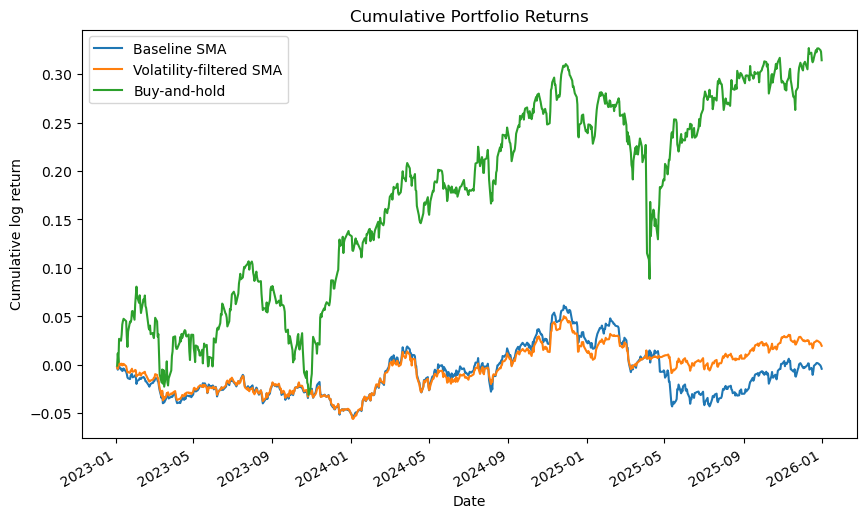

In [26]:
#Compare cumulative returns for baseline SMA, volatility-filtered SMA, and buy-and-hold

comparison_returns = pd.DataFrame(index=portfolio_baseline.index)

comparison_returns["Baseline SMA"] = portfolio_baseline["strategy"]
comparison_returns["Volatility-filtered SMA"] = portfolio_vol_filter["strategy"]
comparison_returns["Buy-and-hold"] = portfolio_baseline["buy_hold"]

comparison_returns.cumsum().plot(figsize=(10, 6), title="Cumulative Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative log return")
plt.show()

In [27]:
#Function to calculate portfolio performance measures
def portfolio_performance(portfolio_df):

    T = len(portfolio_df)

    strategy_return = portfolio_df["strategy"].sum() * (250 / T)
    buy_hold_return = portfolio_df["buy_hold"].sum() * (250 / T)

    strategy_volatility = portfolio_df["strategy"].std() * np.sqrt(250)
    buy_hold_volatility = portfolio_df["buy_hold"].std() * np.sqrt(250)

    strategy_sharpe = strategy_return / strategy_volatility
    buy_hold_sharpe = buy_hold_return / buy_hold_volatility

    return {
        "strategy_return": strategy_return,
        "buy_hold_return": buy_hold_return,
        "strategy_volatility": strategy_volatility,
        "buy_hold_volatility": buy_hold_volatility,
        "strategy_sharpe": strategy_sharpe,
        "buy_hold_sharpe": buy_hold_sharpe}

In [28]:
#Function to calculate maximum drawdown from daily returns
#Max fall from a previous peak 
#log returns converted back to cumulative value series using np.exp
def max_drawdown(returns):
    cumulative_returns = returns.cumsum()
    cumulative_value = np.exp(cumulative_returns)
    #Track highest portfolio value reached so far
    running_max = cumulative_value.cummax()
    #Percentage fall from previous peak
    drawdown = (cumulative_value / running_max) - 1
    return drawdown.min()


#Calculate performance for baseline and volatility-filtered SMA
baseline_results = portfolio_performance(portfolio_baseline)
vol_filter_results = portfolio_performance(portfolio_vol_filter)

#Percentage comparison vs buy-and-hold
#Shows relative outperformance
#abs() used so calc still works if return is negative
baseline_percent_vs_buy_hold = (
    (baseline_results["strategy_return"] - baseline_results["buy_hold_return"])
    / abs(baseline_results["buy_hold_return"])) * 100

vol_filter_percent_vs_buy_hold = (
    (vol_filter_results["strategy_return"] - vol_filter_results["buy_hold_return"])
    / abs(vol_filter_results["buy_hold_return"])) * 100

#Create performance comparison table
performance_table = pd.DataFrame({
   
    "Baseline SMA": [
        baseline_results["strategy_return"],
        baseline_results["strategy_volatility"],
        baseline_results["strategy_sharpe"],
        max_drawdown(portfolio_baseline["strategy"]),
        baseline_results["strategy_return"] - baseline_results["buy_hold_return"],
        baseline_percent_vs_buy_hold],
    
    "Volatility-filtered SMA": [
        vol_filter_results["strategy_return"],
        vol_filter_results["strategy_volatility"],
        vol_filter_results["strategy_sharpe"],
        max_drawdown(portfolio_vol_filter["strategy"]),
        vol_filter_results["strategy_return"] - vol_filter_results["buy_hold_return"],
        vol_filter_percent_vs_buy_hold],
    
    "Buy-and-hold": [
        baseline_results["buy_hold_return"],
        baseline_results["buy_hold_volatility"],
        baseline_results["buy_hold_sharpe"],
        max_drawdown(portfolio_baseline["buy_hold"]),
        0,
        0]

}, index=[
    "Annualised Return",
    "Annualised Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown",
    "Return Difference vs Buy-and-hold",
    "% Difference vs Buy-and-hold"])

performance_table.round(4)

,Baseline SMA,Volatility-filtered SMA,Buy-and-hold
Annualised Return,-0.0014,0.0065,0.1045
Annualised Volatility,0.0598,0.0477,0.1450
Sharpe Ratio,-0.0234,0.1359,0.7206
Maximum Drawdown,-0.0990,-0.0571,-0.1990
Return Difference vs Buy-and-hold,-0.1059,-0.1017,0.0000
% Difference vs Buy-and-hold,-101.3425,-94.0001,0.0000


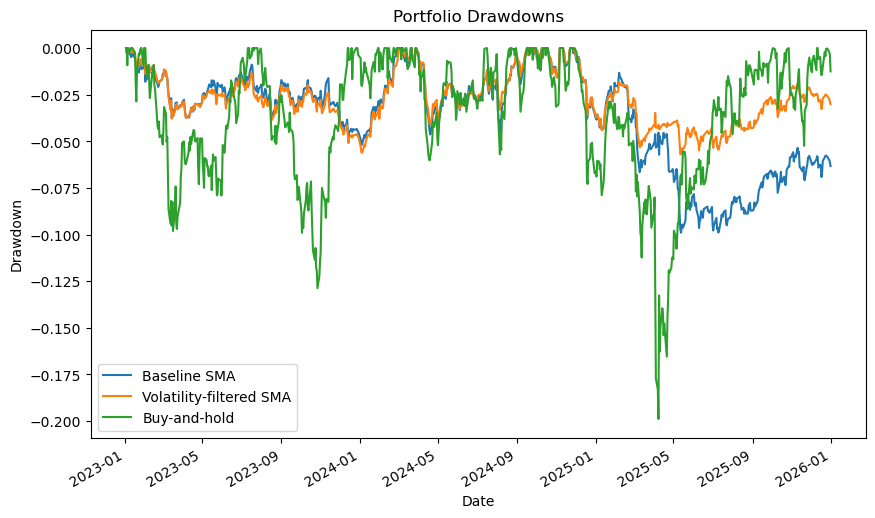

In [29]:
#Create drawdown series for strategies and buy-and-hold

drawdown_df = pd.DataFrame(index=portfolio_baseline.index)

for name, returns in {
    "Baseline SMA": portfolio_baseline["strategy"],
    "Volatility-filtered SMA": portfolio_vol_filter["strategy"],
    "Buy-and-hold": portfolio_baseline["buy_hold"]}.items():
    
    cumulative_returns = returns.cumsum()
    cumulative_value = np.exp(cumulative_returns)
    running_max = cumulative_value.cummax()
    drawdown_df[name] = (cumulative_value / running_max) - 1

drawdown_df.plot(figsize=(10, 6))

plt.title("Portfolio Drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

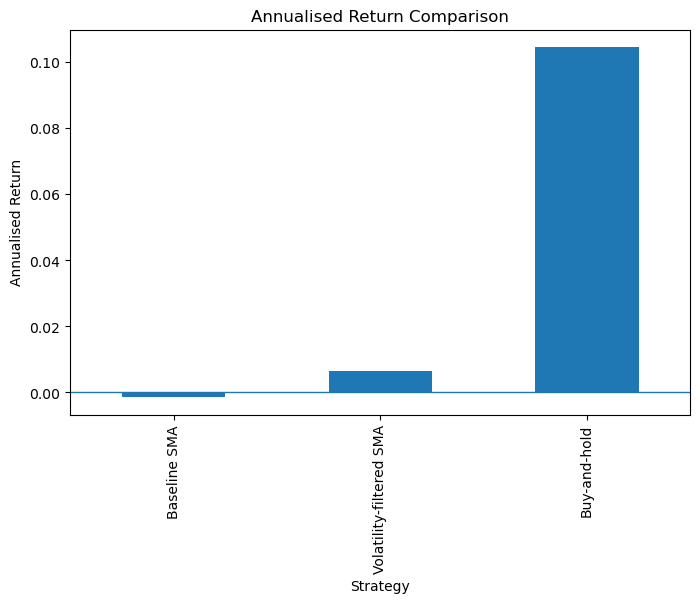

In [30]:
#Plot annualised return comparison

return_comparison = performance_table.loc["Annualised Return"]

return_comparison.plot(kind="bar", figsize=(8, 5))

plt.title("Annualised Return Comparison")
plt.xlabel("Strategy")
plt.ylabel("Annualised Return")
plt.axhline(0, linewidth=1)
plt.show()

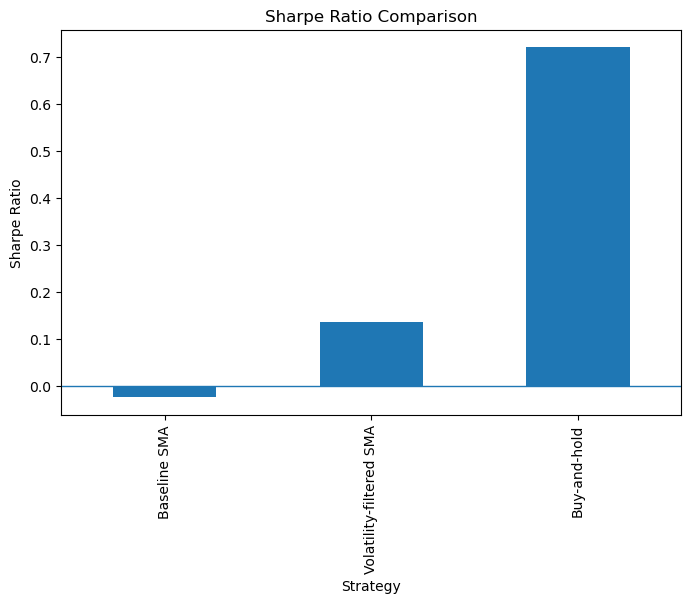

In [31]:
#Plot Sharpe ratio comparison

sharpe_comparison = performance_table.loc["Sharpe Ratio"]

sharpe_comparison.plot(kind="bar", figsize=(8, 5))

plt.title("Sharpe Ratio Comparison")
plt.xlabel("Strategy")
plt.ylabel("Sharpe Ratio")
plt.axhline(0, linewidth=1)
plt.show()